In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from skimage.metrics import peak_signal_noise_ratio
from skimage.metrics import structural_similarity

from qiskit_aer import AerSimulator

In [2]:
IMAGE_SIZE = (16, 16)

input_a_path = "../results/images/image_A.png"
input_b_path = "../results/images/image_B.png"

print("Image processing setup ready.")

Image processing setup ready.


In [3]:
# Create two simple 16x16 grayscale test images

image_A = np.zeros(IMAGE_SIZE, dtype=np.uint8)
image_B = np.zeros(IMAGE_SIZE, dtype=np.uint8)

# Image A: increasing intensity
for i in range(16):
    for j in range(16):
        image_A[i, j] = (i * 6 + j * 4) % 100

# Image B: another pattern
for i in range(16):
    for j in range(16):
        image_B[i, j] = (i * 3 + j * 2) % 80

print("Image A shape:", image_A.shape)
print("Image B shape:", image_B.shape)

print("Maximum Image A pixel:", image_A.max())
print("Maximum Image B pixel:", image_B.max())

Image A shape: (16, 16)
Image B shape: (16, 16)
Maximum Image A pixel: 98
Maximum Image B pixel: 75


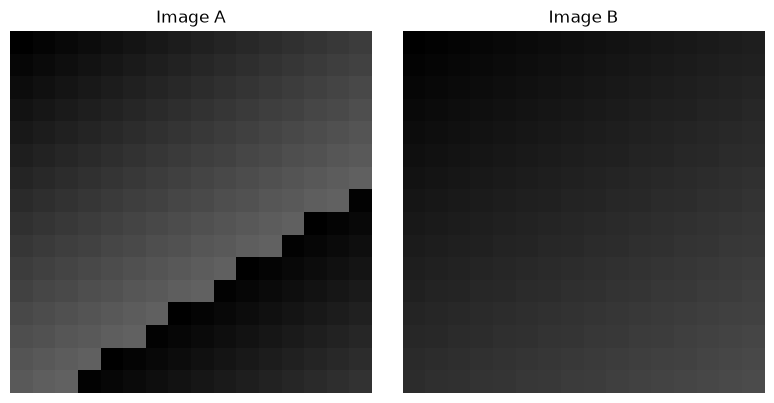

In [4]:
plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(image_A, cmap="gray", vmin=0, vmax=255)
plt.title("Image A")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(image_B, cmap="gray", vmin=0, vmax=255)
plt.title("Image B")
plt.axis("off")

plt.tight_layout()
plt.show()

In [5]:
Image.fromarray(image_A).save(
    "../results/images/image_A.png"
)

Image.fromarray(image_B).save(
    "../results/images/image_B.png"
)

print("Input images saved.")

Input images saved.


In [6]:
simulator = AerSimulator(
    method="matrix_product_state"
)

print("Quantum simulator ready.")

Quantum simulator ready.


In [7]:
def quantum_pixel_operation(a, b, mode):
    """
    Perform one 8-bit quantum addition/subtraction.

    mode = 0 -> addition
    mode = 1 -> subtraction
    """

    qc = create_8bit_adder_subtractor(
        int(a),
        int(b),
        mode
    )

    job = simulator.run(
        qc,
        shots=1
    )

    result = job.result()

    counts = result.get_counts()

    result_value, final_carry = decode_quantum_result(
        counts
    )

    return result_value, final_carry

In [8]:
from qiskit_aer import AerSimulator

# Use the same 8-bit circuit structure
def create_8bit_adder_subtractor(a, b, mode):

    qc = QuantumCircuit(34, 9)

    # Load A
    for i in range(8):
        if (a >> i) & 1:
            qc.x(i)

    # Load B
    for i in range(8):
        if (b >> i) & 1:
            qc.x(8 + i)

    # Mode
    if mode == 1:
        qc.x(16)

    # Initial carry = Mode
    qc.cx(16, 25)

    # 8 ripple stages
    for i in range(8):

        a_bit = i
        b_bit = 8 + i
        result_bit = 17 + i

        carry_in = 25 + i
        carry_out = 26 + i

        # B' = B XOR Mode
        qc.cx(16, b_bit)

        # Result = A XOR B' XOR Carry
        qc.cx(a_bit, result_bit)
        qc.cx(b_bit, result_bit)
        qc.cx(carry_in, result_bit)

        # Carry propagation
        qc.ccx(a_bit, b_bit, carry_out)
        qc.ccx(a_bit, carry_in, carry_out)
        qc.ccx(b_bit, carry_in, carry_out)

        # Restore B
        qc.cx(16, b_bit)

    # Measurement
    for i in range(8):
        qc.measure(17 + i, i)

    qc.measure(33, 8)

    return qc


def decode_quantum_result(counts):

    bitstring = list(counts.keys())[0]

    # Remove spaces if Qiskit displays multiple registers
    bitstring = bitstring.replace(" ", "")

    # Last 8 bits = result
    result_bits = bitstring[-8:]

    # First bit = final carry
    final_carry = int(bitstring[0])

    result_value = int(result_bits, 2)

    return result_value, final_carry


simulator = AerSimulator(
    method="matrix_product_state"
)


def quantum_pixel_operation(a, b, mode):

    qc = create_8bit_adder_subtractor(
        int(a),
        int(b),
        mode
    )

    job = simulator.run(
        qc,
        shots=1
    )

    result = job.result()

    counts = result.get_counts()

    result_value, final_carry = decode_quantum_result(counts)

    return result_value, final_carry


print("Setup ready.")

Setup ready.


In [9]:
qc_test = create_8bit_adder_subtractor(10, 5, 0)

print("Qubits:", qc_test.num_qubits)
print("Classical bits:", qc_test.num_clbits)
print("Depth:", qc_test.depth())

NameError: name 'QuantumCircuit' is not defined

In [ ]:
job = simulator.run(
    qc_test,
    shots=1
)

result = job.result()

counts = result.get_counts()

print(counts)

{'000001111': 1}


In [ ]:
pixel_A = int(image_A[0, 0])
pixel_B = int(image_B[0, 0])

result_pixel, carry = quantum_pixel_operation(
    pixel_A,
    pixel_B,
    mode=0
)

print("Pixel A:", pixel_A)
print("Pixel B:", pixel_B)
print("Quantum addition:", result_pixel)
print("Carry:", carry)
print("Expected:", pixel_A + pixel_B)

Pixel A: 0
Pixel B: 0
Quantum addition: 0
Carry: 0
Expected: 0


In [ ]:
# Recover Image A pixel using subtraction

recovered_pixel, final_carry = quantum_pixel_operation(
    result_pixel,
    pixel_B,
    mode=1
)

# For subtraction:
# final_carry = 1 -> no borrow
# final_carry = 0 -> borrow

borrow = 1 - final_carry

print("Original Pixel A:", pixel_A)
print("Image B Pixel:", pixel_B)
print("Added Pixel:", result_pixel)
print("Recovered Pixel:", recovered_pixel)
print("Borrow:", borrow)

Original Pixel A: 0
Image B Pixel: 0
Added Pixel: 0
Recovered Pixel: 0
Borrow: 0


In [ ]:
if recovered_pixel == pixel_A:
    print("Pixel recovery: PASS")
else:
    print("Pixel recovery: FAIL")

Pixel recovery: PASS


In [ ]:
test_A = 25
test_B = 10

# Addition
added_test, carry_test = quantum_pixel_operation(
    test_A,
    test_B,
    mode=0
)

# Recovery by subtraction
recovered_test, final_carry_test = quantum_pixel_operation(
    added_test,
    test_B,
    mode=1
)

borrow_test = 1 - final_carry_test

print("Test A:", test_A)
print("Test B:", test_B)
print("A + B:", added_test)
print("Expected addition:", test_A + test_B)
print("Recovered A:", recovered_test)
print("Expected recovery:", test_A)
print("Borrow:", borrow_test)

Test A: 25
Test B: 10
A + B: 35
Expected addition: 35
Recovered A: 25
Expected recovery: 25
Borrow: 0


In [ ]:
if added_test == test_A + test_B and recovered_test == test_A:
    print("Non-zero pixel test: PASS")
else:
    print("Non-zero pixel test: FAIL")

Non-zero pixel test: PASS


In [ ]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Load images
image_A = np.array(
    Image.open("../results/images/image_A.png").convert("L")
)

image_B = np.array(
    Image.open("../results/images/image_B.png").convert("L")
)

print("Image A shape:", image_A.shape)
print("Image B shape:", image_B.shape)
print("Image A data type:", image_A.dtype)
print("Image B data type:", image_B.dtype)

Image A shape: (16, 16)
Image B shape: (16, 16)
Image A data type: uint8
Image B data type: uint8


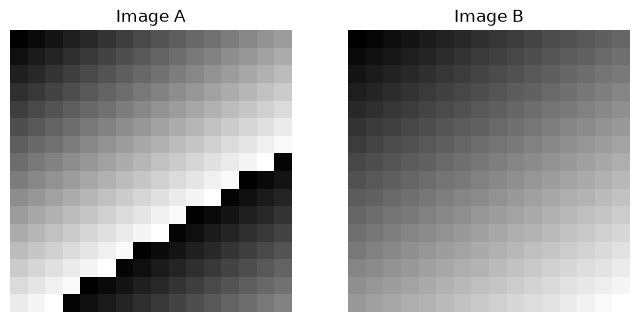

In [ ]:
plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(image_A, cmap="gray")
plt.title("Image A")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(image_B, cmap="gray")
plt.title("Image B")
plt.axis("off")

plt.show()

In [ ]:
if image_A.shape == image_B.shape:
    print("Image dimensions match.")
else:
    print("ERROR: Image dimensions do not match.")

Image dimensions match.


In [ ]:
def quantum_image_addition(image_A, image_B):
    """
    Add two grayscale images pixel-by-pixel
    using the 8-bit Qiskit adder-cum-subtractor.

    mode = 0 -> addition
    """

    height, width = image_A.shape

    result_image = np.zeros(
        (height, width),
        dtype=np.uint8
    )

    carry_image = np.zeros(
        (height, width),
        dtype=np.uint8
    )

    for i in range(height):
        for j in range(width):

            pixel_A = int(image_A[i, j])
            pixel_B = int(image_B[i, j])

            result_pixel, carry = quantum_pixel_operation(
                pixel_A,
                pixel_B,
                mode=0
            )

            result_image[i, j] = result_pixel
            carry_image[i, j] = carry

    return result_image, carry_image


print("Quantum image addition function ready.")

Quantum image addition function ready.


In [ ]:
image_C, carry_image = quantum_image_addition(
    image_A,
    image_B
)

print("Quantum image addition completed.")
print("Output image shape:", image_C.shape)
print("Output data type:", image_C.dtype)

Quantum image addition completed.
Output image shape: (16, 16)
Output data type: uint8


In [ ]:
overflow_pixels = np.sum(carry_image)

print("Number of pixels with carry/overflow:", overflow_pixels)

Number of pixels with carry/overflow: 0


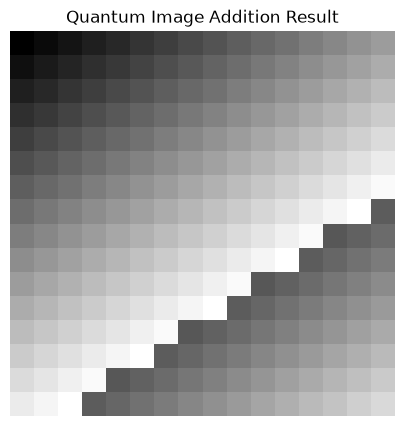

In [ ]:
plt.figure(figsize=(5, 5))

plt.imshow(image_C, cmap="gray")
plt.title("Quantum Image Addition Result")
plt.axis("off")

plt.show()

In [ ]:
output_path = "../results/images/image_C.png"

Image.fromarray(image_C).save(output_path)

print("Image C saved to:", output_path)

Image C saved to: ../results/images/image_C.png


In [ ]:
def quantum_image_recovery(image_C, image_B):
    """
    Recover Image A from:
    
    Image C - Image B = Image A
    
    mode = 1 -> subtraction
    """

    height, width = image_C.shape

    recovered_image = np.zeros(
        (height, width),
        dtype=np.uint8
    )

    borrow_image = np.zeros(
        (height, width),
        dtype=np.uint8
    )

    for i in range(height):
        for j in range(width):

            pixel_C = int(image_C[i, j])
            pixel_B = int(image_B[i, j])

            recovered_pixel, final_carry = quantum_pixel_operation(
                pixel_C,
                pixel_B,
                mode=1
            )

            # For subtraction:
            # final_carry = 1 -> no borrow
            # final_carry = 0 -> borrow
            borrow = 1 - final_carry

            recovered_image[i, j] = recovered_pixel
            borrow_image[i, j] = borrow

    return recovered_image, borrow_image


print("Quantum image recovery function ready.")

Quantum image recovery function ready.


In [ ]:
recovered_A, borrow_image = quantum_image_recovery(
    image_C,
    image_B
)

print("Quantum image recovery completed.")
print("Recovered image shape:", recovered_A.shape)
print("Recovered image data type:", recovered_A.dtype)

Quantum image recovery completed.
Recovered image shape: (16, 16)
Recovered image data type: uint8


In [ ]:
recovered_path = "../results/images/recovered_A.png"

Image.fromarray(recovered_A).save(recovered_path)

print("Recovered image saved to:", recovered_path)

Recovered image saved to: ../results/images/recovered_A.png


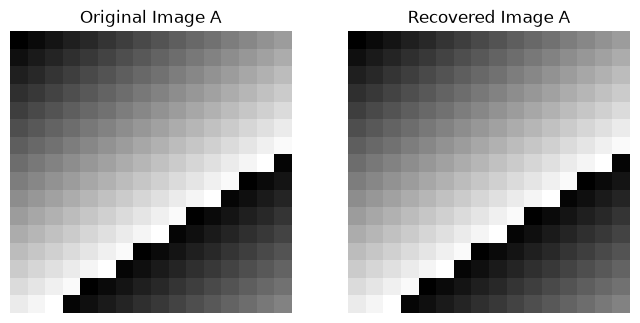

In [ ]:
plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(image_A, cmap="gray")
plt.title("Original Image A")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(recovered_A, cmap="gray")
plt.title("Recovered Image A")
plt.axis("off")

plt.show()

In [ ]:
difference = np.abs(
    image_A.astype(np.int16) -
    recovered_A.astype(np.int16)
)

print("Maximum pixel difference:", difference.max())
print("Total absolute error:", difference.sum())
print("Different pixels:", np.count_nonzero(difference))

Maximum pixel difference: 0
Total absolute error: 0
Different pixels: 0


In [ ]:
if np.array_equal(image_A, recovered_A):
    print("Image recovery: PERFECT")
else:
    print("Image recovery: DIFFERENCE FOUND")

Image recovery: PERFECT


In [ ]:
from skimage.metrics import peak_signal_noise_ratio
from skimage.metrics import structural_similarity

print("PSNR and SSIM functions loaded.")

PSNR and SSIM functions loaded.


In [ ]:
psnr_value = peak_signal_noise_ratio(
    image_A,
    recovered_A,
    data_range=255
)

print("PSNR:", psnr_value)

PSNR: inf


c:\Users\nandi\OneDrive\Desktop\CSM-07-Project-Quantum-Adders-and-Subtractors\.venv\Lib\site-packages\skimage\metrics\simple_metrics.py:171: RuntimeWarning: divide by zero encountered in scalar divide
  return 10 * np.log10((data_range**2) / err)


In [ ]:
ssim_value = structural_similarity(
    image_A,
    recovered_A,
    data_range=255
)

print("SSIM:", ssim_value)

SSIM: 1.0


In [ ]:
print("Image Recovery Metrics")
print("----------------------")
print("Maximum Pixel Difference:", difference.max())
print("Total Absolute Error:", difference.sum())
print("Different Pixels:", np.count_nonzero(difference))
print("PSNR:", psnr_value)
print("SSIM:", ssim_value)

Image Recovery Metrics
----------------------
Maximum Pixel Difference: 0
Total Absolute Error: 0
Different Pixels: 0
PSNR: inf
SSIM: 1.0


In [ ]:
import pandas as pd

image_metrics = pd.DataFrame({
    "Metric": [
        "Maximum Pixel Difference",
        "Total Absolute Error",
        "Different Pixels",
        "PSNR",
        "SSIM"
    ],
    "Value": [
        int(difference.max()),
        int(difference.sum()),
        int(np.count_nonzero(difference)),
        psnr_value,
        ssim_value
    ]
})

image_metrics.to_csv(
    "../results/tables/image_recovery_metrics.csv",
    index=False
)

print("Image recovery metrics saved.")

Image recovery metrics saved.


In [ ]:
image_summary = pd.DataFrame({
    "Parameter": [
        "Image Height",
        "Image Width",
        "Total Pixels",
        "Maximum Pixel Difference",
        "Total Absolute Error",
        "Different Pixels",
        "PSNR",
        "SSIM",
        "Image Recovery"
    ],
    "Value": [
        image_A.shape[0],
        image_A.shape[1],
        image_A.size,
        int(difference.max()),
        int(difference.sum()),
        int(np.count_nonzero(difference)),
        psnr_value,
        ssim_value,
        "PERFECT" if np.array_equal(image_A, recovered_A) else "DIFFERENCE FOUND"
    ]
})

image_summary.to_csv(
    "../results/tables/image_processing_summary.csv",
    index=False
)

print("Final image-processing summary saved.")
print(image_summary)

Final image-processing summary saved.
                  Parameter    Value
0              Image Height       16
1               Image Width       16
2              Total Pixels      256
3  Maximum Pixel Difference        0
4      Total Absolute Error        0
5          Different Pixels        0
6                      PSNR      inf
7                      SSIM      1.0
8            Image Recovery  PERFECT
